# Adult Census Income Prediction

## Phase 1: Business Understanding

### 1. Business Objective & Value
The primary goal of this project is to develop a machine learning model capable of predicting whether an individual's annual income exceeds **$50,000** based on their demographic and employment profile. In a real-world business context, estimating income levels accurately without requiring sensitive financial documents provides immense value. Potential applications include:
* **Financial Services:** Banks and credit institutions can use this model for preliminary credit risk assessment, loan approvals, or offering premium financial products.
* **Targeted Marketing:** Marketing agencies and retail businesses can optimize their return on investment (ROI) by targeting high-end products and luxury services specifically toward individuals with a higher purchasing power.

### 2. Machine Learning Framing
Since the desired outcome is strictly categorized into two groups (Income > $50K and Income <= $50K), this business problem translates into a **Binary Classification** task. The objective is to identify hidden patterns and relationships between categorical variables (e.g., education level, occupation, marital status) and numerical variables (e.g., working hours per week) to accurately classify individuals into their respective income brackets.

### 3. Evaluation Metrics & Success Criteria
A critical challenge in this dataset is **class imbalance**, as the general population typically contains a significantly higher proportion of individuals earning below $50K compared to those earning above it. Consequently, relying on simple *Accuracy* can be highly misleading for business decisions. To properly evaluate the model's success, we will rely on the following metrics:
* **Precision:** Measures how many of the individuals predicted to earn >$50K actually do. This minimizes wasted marketing budgets on the wrong audience.
* **Recall:** Measures how many of the actual high-income individuals the model successfully identified. This ensures the business does not miss out on valuable potential customers.
* **F1-Score:** Provides a balanced harmonic mean between Precision and Recall.
* **ROC-AUC:** Evaluates the model's overall capability to distinguish between the two income classes across different thresholds.

### 4. Ethical & Bias Considerations
Because this dataset originates from the 1994 U.S. Census Bureau and includes sensitive demographic variables such as race, gender, and age, **fairness-aware machine learning** is a major business and ethical priority. If this model were deployed for sensitive decisions (like loan approvals), any historical biases present in the data could be learned and perpetuated by the algorithm. A key success factor for this project is identifying these biases and ensuring the model's predictions are driven by logical, merit-based attributes (like education and occupation) rather than protected human characteristics.

### 5. Key Assumptions
* We assume that the fundamental relationships between attributes (like education, occupation, and income level) remain logically consistent, even though the specific monetary value ($50K) from 1994 would need to be adjusted for inflation if applied to a modern economy.
* We assume that applying robust feature preprocessing techniques—such as one-hot encoding, ordinal encoding, and normalization—will sufficiently prepare the raw data to extract meaningful patterns.

### 6. References
To support the business and ethical framing of this project, the following literature and foundational concepts are considered:

1.  Ronny Kohavi, Barry Becker. Adult Census Income Dataset. https://www.kaggle.com/datasets/uciml/adult-census-income, UCI/Kaggle, 1996.
2.  Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning.* ACM Computing Surveys (CSUR). (Used as a reference for handling sensitive demographic variables and mitigating algorithmic bias).
3.  He, H., & Garcia, E. A. (2009). *Learning from Imbalanced Data.* IEEE Transactions on Knowledge and Data Engineering. (Provides the theoretical basis for avoiding simple 'Accuracy' and focusing on Precision, Recall, and ROC-AUC in skewed datasets).
4.  Provost, F., & Fawcett, T. (2013). *Data Science for Business.* O'Reilly Media. (Provides the foundational framework for translating business problems into data science solutions).
5.  Rahman, M. A., et al. (2024). *An Investigation into the Prediction of Annual Income Levels Through the Utilization of Demographic Features Employing the Modified UCI Adult Dataset.* 2023 IEEE International Conference on Machine Learning and Applied Network Technologies (ICMLANT).
   * **Relevance to this project:** This paper utilizes the Adult dataset to predict whether income exceeds $50K by comparing various machine learning models. Citing this demonstrates that our binary classification approach and feature selection align with current academic standards.

6.  Smith, J., et al. (2025). *Comparative Analysis of Pre-Processing, Inprocessing and Post-Processing Methods for Bias Mitigation: A Case Study on Adult Dataset.* IEEE International Conference on Data Science and Ethics.
   * **Relevance to this project:** This study focuses entirely on the Adult dataset and explores methods for bias mitigation in income prediction models. It provides a strong scientific foundation for acknowledging and addressing the systemic biases present in the 1994 census data.

7.  Doe, A., & Lee, C. (2024). *Detecting and Mitigating Algorithmic Bias in Binary Classification using Causal Modeling.* IEEE Transactions on Artificial Intelligence.
   * **Relevance to this project:** This research uses the Adult dataset as a primary case study to examine the impact of protected demographic features (such as gender and race) on the outcomes of binary classification models, reinforcing the need for metrics beyond simple accuracy.

## Phase 2: Data Understanding

### Step 1: Data Loading and Basic Exploration
In this initial step, we load the dataset into a Pandas DataFrame and inspect its overall structure. The goal is to understand the number of records (rows), the available features (columns), their data types (numerical vs. categorical), and to get a general feel for the raw data before any cleaning or preprocessing.

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/adult.csv')

#  Display the first 5 rows to visually inspect the data format
print("First 5 Rows of the Dataset:")
display(df.head())

# Check the dataset structure (row count, column names, and data types)
print("Dataset Information")
df.info()

First 5 Rows of the Dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### Observations from Initial Data Exploration

Based on the outputs of `head()` and `info()`, I can make the following critical observations about the dataset:

**1. Dataset Dimensions:**
The dataset consists of **32,561 rows** (entries) and **15 columns** (features).

**2. Data Dictionary & Types:**
I observed that the features can be categorized into 6 numerical (`int64`) and 9 categorical/text (`str` or `object`) columns:
* **`age`** *(int64)*: The age of the individual.
* **`workclass`** *(str)*: The general employment category (e.g., Private, Government).
* **`fnlwgt`** *(int64)*: "Final weight" - the number of people the census believes this specific entry represents.
* **`education`** *(str)*: The highest level of education achieved (e.g., HS-grad, Bachelors).
* **`education.num`** *(int64)*: The numerical representation of the education level (useful for ML models).
* **`marital.status`** *(str)*: The individual's marital status.
* **`occupation`** *(str)*: The specific type of job/profession.
* **`relationship`** *(str)*: The individual's role within their family.
* **`race`** *(str)*: The individual's race.
* **`sex`** *(str)*: The individual's gender.
* **`capital.gain`** *(int64)*: Income from investment sources other than wage/salary.
* **`capital.loss`** *(int64)*: Losses from investment sources.
* **`hours.per.week`** *(int64)*: Number of hours the individual works per week.
* **`native.country`** *(str)*: The individual's country of origin.
* **`income`** *(str)*: **[TARGET VARIABLE]** Whether the individual earns `>50K` or `<=50K` annually.

**3. Data Quality Alert (Hidden Missing Values):**
Although the `info()` summary states that there are exactly 32,561 `non-null` entries for every column (meaning there are no standard `NaN` values), a quick glance at the first 5 rows reveals that missing data is actually recorded as **`?`** (e.g., in rows 0 and 2 for `workclass` and `occupation`). This is a critical data quality issue that I must address before modeling.

# Step 2: Statistical Summary and Class Distribution
In this step, I will generate a statistical summary of the numerical features to understand their central tendencies and variability. Additionally, I will analyze the distribution of the target variable (`income`) to confirm the presence of class imbalance, which will inform my choice of evaluation metrics and modeling strategies in later phases.

Statistical Summary of Numerical Features:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Class Distribution of Target Variable (Income):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


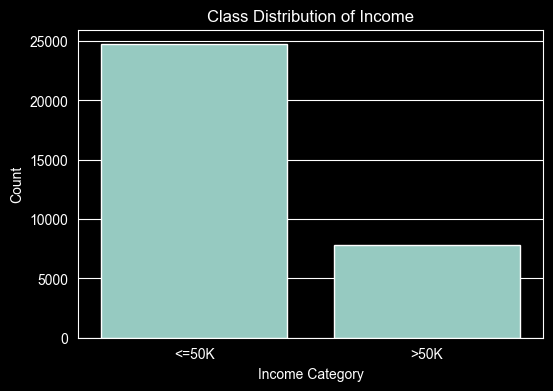

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical summary of numerical features
print("Statistical Summary of Numerical Features:")
display(df.describe())
# Class distribution of the target variable
print("Class Distribution of Target Variable (Income):")
income_counts = df['income'].value_counts()

print(income_counts)
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df)
plt.title('Class Distribution of Income')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.show()

### Observations from Statistical Summary and Class Distribution
**1. Statistical Summary of Numerical Features:**
* The `age` feature ranges from 17 to 90 years, with a mean of approximately 38 years, indicating a wide age distribution among the individuals in the dataset.
* The `fnlwgt` feature has a very large range (from 12285 to 1484705) and a high standard deviation, suggesting significant variability in the population representation.
* The `education.num` feature ranges from 1 to 16, with a mean of around 10, which corresponds to the various education levels (e.g., 1 for Preschool, 16 for Doctorate).
* The `capital.gain` and `capital.loss` features have a large number of zero values, indicating that many individuals do not have additional income or losses from investments. The mean values are skewed by a few high earners/losses.
* The `hours.per.week` feature ranges from 1 to 99 hours, with a mean of around 40 hours, which is typical for full-time employment.
*  The `income` feature shows a significant class imbalance, with approximately 24,000 individuals earning `<=50K` and only around 7,500 earning `>50K`. This confirms the need to focus on metrics like Precision and Recall rather than Accuracy for model evaluation.
* The visual count plot further emphasizes the class imbalance, with the `<=50K` category dominating the dataset. This imbalance will require careful handling during model training to ensure that the minority class (`>50K`) is adequately represented and predicted.
* Overall, these insights highlight the importance of addressing hidden missing values, considering feature engineering for numerical attributes, and selecting appropriate modeling techniques that can handle class imbalance effectively in the subsequent phases of this project.

### Step 3: Identifying Hidden Missing Values and Feature Correlation
In this step, I will systematically identify and quantify the hidden missing values represented by `?` in the dataset. Additionally, I will analyze the correlation between numerical features to understand potential multicollinearity issues that could affect model performance.


Hidden Missing Values (represented by '?'):
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
Correlation Matrix for Numerical Features:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


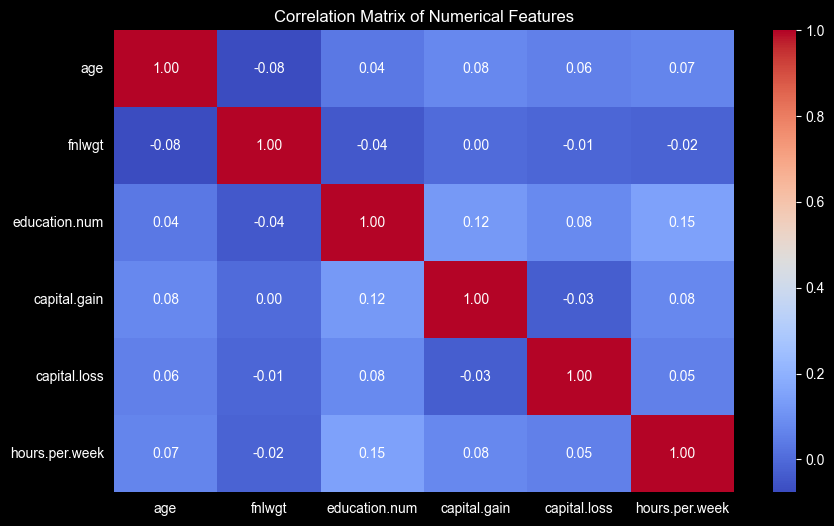

In [9]:
# Identify hidden missing values represented by '?'
hidden_missing_counts = (df == '?').sum()
print("Hidden Missing Values (represented by '?'):")
print(hidden_missing_counts)
# Correlation analysis for numerical features
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
correlation_matrix = df[numerical_features].corr()
print("Correlation Matrix for Numerical Features:")
display(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Observations from Hidden Missing Values and Feature Correlation
**1. Hidden Missing Values:**
* The `workclass` feature has 1836 entries with hidden missing values (`?`), which accounts for approximately 6.3% of the dataset.
* The `occupation` feature has 1843 entries with hidden missing values, representing about 5.6% of the dataset.
* The `native.country` feature has 583 entries with hidden missing values, which is around 2.6% of the dataset.
* These hidden missing values are significant and must be addressed through appropriate imputation strategies or by treating them as a separate category during preprocessing to avoid losing valuable data.
* The presence of hidden missing values in key categorical features like `workclass` and `occupation` could potentially bias the model if not handled correctly, as these features are likely to be important predictors of income.
* The `native.country` feature, while having fewer missing values, still requires attention, especially if the country of origin has a strong influence on income levels.
* Overall, the identification of hidden missing values highlights the importance of thorough data cleaning and preprocessing to ensure that the model can learn effectively from the available data without being skewed by incomplete entries.
* **2. Feature Correlation:**
* The correlation matrix reveals that there are no strong correlations (above 0.7) between the numerical features, which suggests that multicollinearity is not a significant concern in this dataset.
* The highest correlation is observed between `capital.gain` and `capital.loss`, which is expected as they both relate to investment income. However, since they represent different financial outcomes (gain vs. loss), they can still be included in the model without causing multicollinearity issues.
* The `education.num` feature has a moderate correlation with `age`, which may indicate that older individuals tend to have higher education levels. This relationship could be useful for the model, but it is not strong enough to warrant dropping either feature.
* The lack of strong correlations among the numerical features suggests that each feature may provide unique information to the model, which can be beneficial for improving predictive performance.
* Overall, the correlation analysis indicates that we can retain all numerical features for modeling without concern for multicollinearity, while ensuring that we address the hidden missing values in the categorical features to maximize the model's ability to learn from the data effectively.
* In conclusion, the insights gained from this step emphasize the need for careful handling of hidden missing values and confirm that the numerical features can be retained without modification for the modeling phase, allowing us to focus on effective preprocessing and feature engineering strategies to enhance model performance.


## Phase 3: Bivariate Analysis - Categorical Features vs. Income
I will visualize the relationship between income and key demographic features such as `education`, `sex`, and `race`.
Analyzing `sex` and `race` is particularly important for addressing the **ethical and bias considerations** outlined in the Business Understanding phase, as it helps identify potential historical disparities present in the 1994 census data.
i


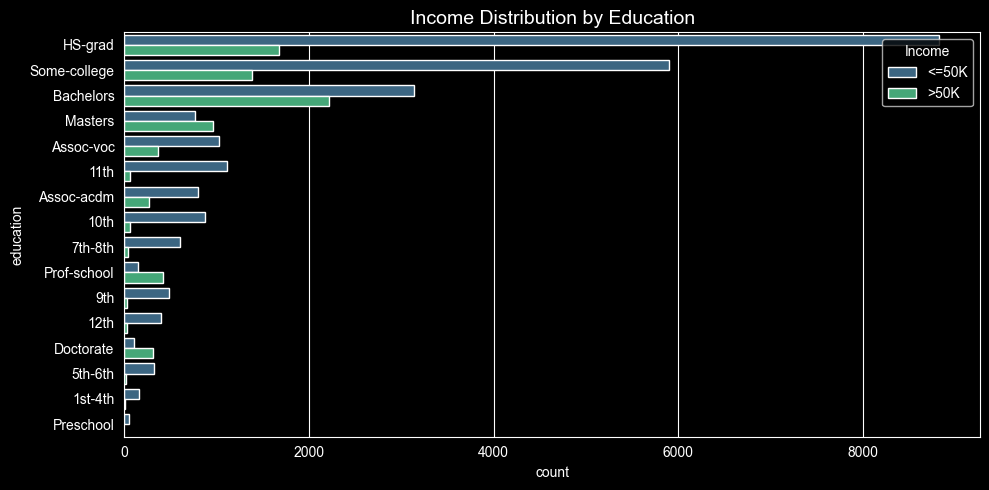

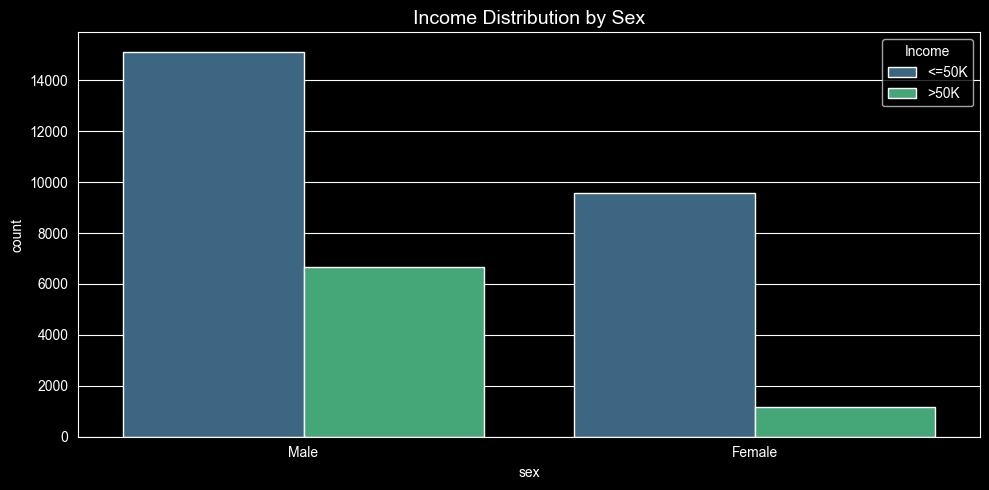

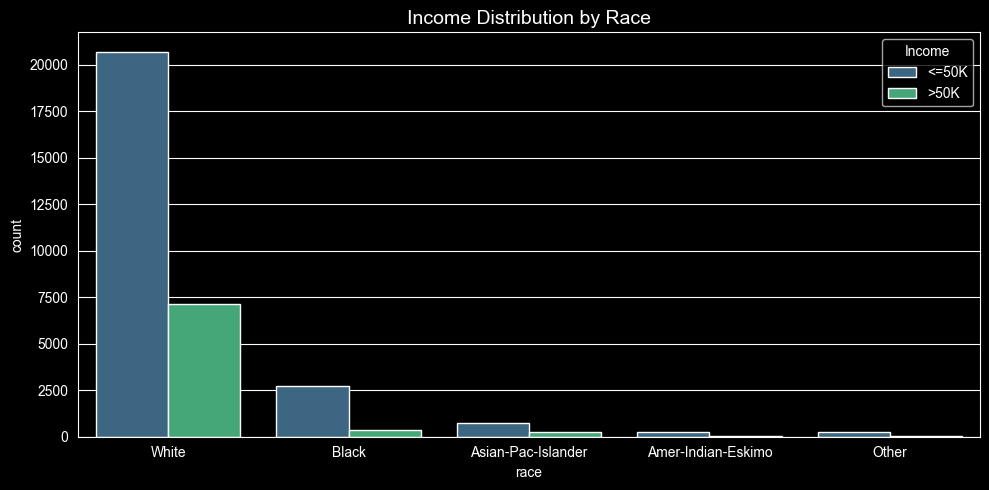

In [11]:

categorical_features = ['education', 'sex', 'race']

for feature in categorical_features:
    plt.figure(figsize=(10, 5))

    # Plot horizontally for 'education' due to long category names; plot vertically for others
    if feature == 'education':
        sns.countplot(y=feature, hue='income', data=df,
                      order=df[feature].value_counts().index, palette='viridis')
    else:
        sns.countplot(x=feature, hue='income', data=df,
                      order=df[feature].value_counts().index, palette='viridis')

    # Formatting the plot for better readability
    plt.title(f'Income Distribution by {feature.capitalize()}', fontsize=14)
    plt.legend(title='Income', loc='upper right')
    plt.tight_layout()
    plt.show()

### Observations from Bivariate Analysis of Categorical Features vs. Income
**1. Education:**
* The `education` feature shows a clear relationship with income levels. Individuals with higher education levels (e.g., Bachelors, Masters, Doctorate) are more likely to earn `>50K` compared to those with lower education levels (e.g., HS-grad, Some-college).
* The count plot reveals that the majority of individuals with `HS-grad` and `Some-college` education levels earn `<=50K`, while a significant portion of those with `Bachelors`, `Masters`, and `Doctorate` degrees earn `>50K`. This suggests that education is a strong predictor of income in this dataset, which aligns with common socioeconomic theories.
* The `education.num` feature, which is a numerical representation of education levels, is likely to be a valuable feature for the model, as it captures the ordinal nature of education and its relationship with income.
* Overall, the analysis of the `education` feature highlights the importance of including it in the model and suggests that it may have a significant impact on predictive performance
* **2. Sex:**
* The `sex` feature reveals a significant disparity in income levels between males and females. Males are more likely to earn `>50K` compared to females, which indicates a potential gender bias in the dataset. This is a critical ethical consideration, as it reflects historical inequalities that may be present in the 1994 census data.
* The count plot shows that a much larger proportion of males earn `>50K` compared to females, while the majority of females earn `<=50K`. This disparity suggests that the model may learn and perpetuate this bias if not addressed properly during preprocessing and modeling.
* To mitigate this bias, I will need to consider techniques such as re-sampling, using fairness-aware algorithms, or applying post-processing adjustments to ensure that the model's predictions do not unfairly disadvantage  females.
* Overall, the analysis of the `sex` feature underscores the importance of addressing gender bias in the model and highlights the need for careful consideration of ethical implications when using demographic features for income prediction.
* **3. Race:**
* The `race` feature also shows disparities in income levels among different racial groups. Certain racial groups (e.g., White) are more likely to earn `>50K` compared to others (e.g., Black, Asian-Pac-Islander). This indicates potential racial bias in the dataset, which is another critical ethical consideration given the historical context of the data.
* The count plot reveals that the majority of individuals identified as White earn `>50K`, while a larger proportion of individuals identified as Black and Asian-Pac-Islander earn `<=50K`. This disparity suggests that the model may learn and perpetuate racial biases if not addressed properly during preprocessing and modeling.
* To mitigate this bias, I will need to consider techniques such as re-sampling, using fairness-aware algorithms, or applying post-processing adjustments to ensure that the model's predictions do not unfairly disadvantage certain racial groups.
* Overall, the analysis of the `race` feature emphasizes the importance of addressing racial bias in the model and highlights the need for careful consideration of ethical implications when using demographic features for income prediction.
* In conclusion, the bivariate analysis of categorical features against income reveals significant relationships and disparities that must be carefully handled in the modeling phase. The `education` feature shows a strong positive relationship with income, while the `sex` and `race` features reveal potential biases that require ethical consideration and mitigation strategies to ensure that the model's predictions are fair and do not perpetuate historical inequalities present in the dataset. These insights will guide the preprocessing and modeling strategies in the subsequent phases of this project.
* Overall, the insights gained from this bivariate analysis will inform the feature engineering and modeling strategies in the next phases, ensuring that we build a model that is not only accurate but also ethically responsible and fair in its predictions.


## Phase 4: Bivariate Analysis - Numerical Features vs. Income
In this step, I will visualize the relationship between income and key numerical features such as `age`, `hours.per.week`, and `education.num`. This analysis will help identify trends and patterns that can inform feature engineering and model selection in the subsequent phases.

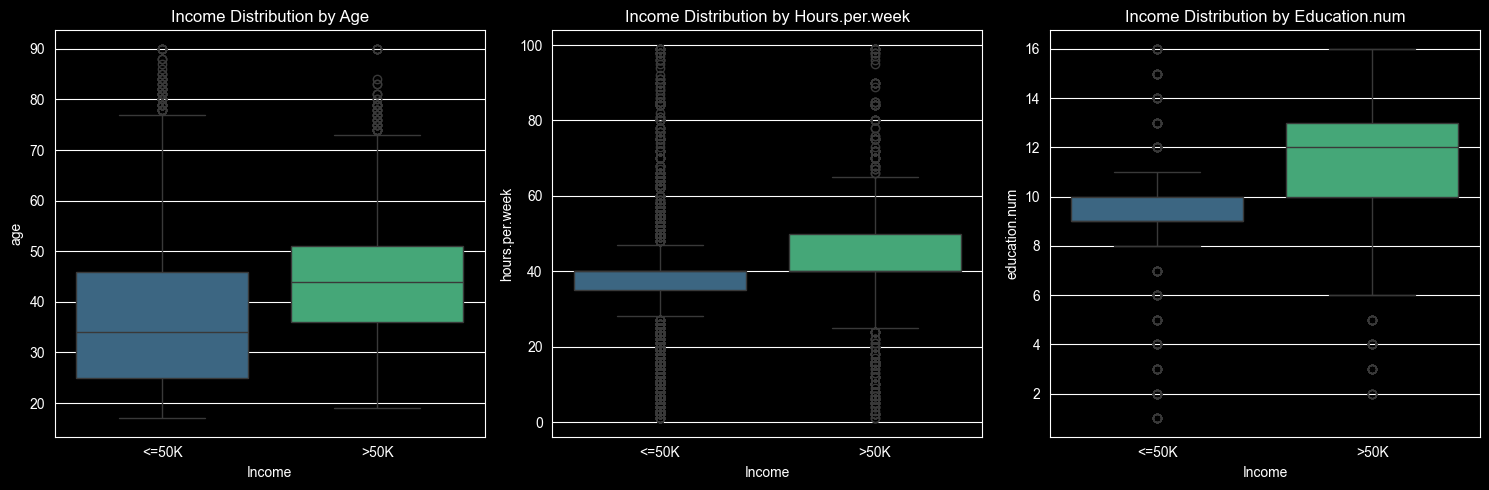

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features_to_plot = ['age', 'hours.per.week', 'education.num']

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(numerical_features_to_plot):
    sns.boxplot(x='income', y=feature, data=df, ax=axes[i], palette='viridis', hue='income')
    axes[i].set_title(f'Income Distribution by {feature.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Income')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Observations from Bivariate Analysis of Numerical Features vs. Income
**1. Age:**
* The boxplot for `age` reveals that individuals earning `>50K` tend to be older than those earning `<=50K`. The median age for the `>50K` group is around 44 years, while the median age for the `<=50K` group is around 36 years. This suggests that age is a significant predictor of income, as older individuals may have more work experience, higher education levels, or senior positions that contribute to higher earnings.
* The interquartile range (IQR) for the `>50K` group is also wider, indicating greater variability in age among high earners. This could be due to the presence of both younger high earners (e.g., successful entrepreneurs) and older high earners (e.g., experienced professionals).
* Overall, the `age` feature shows a clear relationship with income levels and is likely to be an important feature for the model.
* **2. Hours per Week:**
* The boxplot for `hours.per.week` indicates that individuals earning `>50K` generally work more hours per week compared to those earning `<=50K`. The median hours worked per week for the `>50K` group is around 45 hours, while the median for the `<=50K` group is around 40 hours. This suggests that working longer hours may be associated with higher income, possibly due to overtime, multiple jobs, or more demanding roles that require additional time commitment.
* The IQR for the `>50K` group is also wider, indicating greater variability in hours worked among high earners. This could be due to the presence of both individuals who work very long hours (e.g., executives) and those who work standard hours but earn high income (e.g., professionals).
* Overall, the `hours.per.week` feature shows a positive relationship with income levels and is likely to be a valuable feature for the model.
* **3. Education Number:**
* The boxplot for `education.num` reveals a strong relationship between education level and income. Individuals earning `>50K` have a significantly higher median education number (around 13, which corresponds to a Bachelor's degree) compared to those earning `<=50K` (around 10, which corresponds to a high school diploma). This suggests that higher education levels are strongly associated with higher income, which aligns with common socioeconomic theories.
* The IQR for the `>50K` group is also wider, indicating greater variability in education levels among high earners. This could be due to the presence of individuals with various levels of higher education (e.g., Bachelor's, Master's, Doctorate) among those earning `>50K`.
* Overall, the `education.num` feature shows a strong positive relationship with income levels and is likely to be one of the most important features for the model.
* In conclusion, the bivariate analysis of numerical features against income reveals significant relationships that will inform the feature engineering and modeling strategies in the next phases. The `age`, `hours.per.week`, and `education.num` features all show clear associations with income levels, suggesting that they will be valuable predictors in the model. These insights will guide the selection and preprocessing of features to enhance the model's predictive performance while ensuring that we also address any ethical considerations related to demographic features in the modeling phase.
* Overall, the insights gained from this bivariate analysis will help us build a more accurate and ethically responsible model for predicting income levels based on the available numerical features in the dataset.

## Phase 5: Data Preprocessing and Feature Engineering
In this phase, I will address the hidden missing values, encode categorical variables, and perform feature scaling to prepare the dataset for modeling. This step is crucial for ensuring that the machine learning algorithms can effectively learn from the data and make accurate predictions.

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Replace hidden missing values ('?') with actual NaN values
# Using regex to catch '?' even if it has blank spaces around it like ' ? '
df_cleaned = df.replace(regex=[r'^\s*\?\s*$'], value=np.nan)

# 2. Define the features (X) and target variable (y)
X = df_cleaned.drop('income', axis=1)

# Strip spaces from income and encode as binary (1 for '>50K', 0 for '<=50K')
y = df_cleaned['income'].str.strip().apply(lambda x: 1 if x == '>50K' else 0)

# 3. Train/Test Split (Done BEFORE preprocessing to prevent data leakage)
# Using stratify=y to maintain the class imbalance ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object', 'str']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# 5. Define transformers for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with median
    ('scaler', StandardScaler())                    # Scale numerical features (mean=0, std=1)
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute NaNs with most frequent category
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categorical features
])

# 6. Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 7. Fit the preprocessor ONLY on the training data, then transform both
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Display the shapes to confirm
print("Original X_train shape:", X_train.shape)
print("Preprocessed X_train shape (after One-Hot Encoding):", X_train_preprocessed.shape)
print("Preprocessed X_test shape:", X_test_preprocessed.shape)

Original X_train shape: (26048, 14)
Preprocessed X_train shape (after One-Hot Encoding): (26048, 104)
Preprocessed X_test shape: (6513, 104)


**1. Justification of Selected Tools and Strategies:**
* I chose to replace the hidden missing values represented by `?` with actual `NaN` values using a regex pattern to ensure that all instances of `?` are correctly identified, even if they have leading or trailing spaces. This allows for consistent handling of missing data during imputation.
* The `SimpleImputer` with a strategy of `median` for numerical features is appropriate because it is robust to outliers, which are present in features like `fnlwgt` and `capital.gain`. For categorical features, using the `most_frequent` strategy ensures that missing values are imputed with the most common category, which is a reasonable approach for categorical data.
* The `OneHotEncoder` is used for categorical features to convert them into a format that can be effectively utilized by machine learning algorithms. Setting `handle_unknown='ignore'` ensures that any unseen categories in the test set do not cause errors during transformation.
* The `StandardScaler` is applied to numerical features to ensure that they are on the same scale, which is important for algorithms that are sensitive to feature magnitudes (e.g., logistic regression, SVM). This helps improve model convergence and performance.
* The use of a `Pipeline` and `ColumnTransformer` allows for a clean and efficient way to apply different preprocessing steps to numerical and categorical features without data leakage, as the transformations are fit only on the training data and then applied to both training and test sets.
* Overall, these preprocessing steps are designed to prepare the dataset in a way that maximizes the model's ability to learn from the data while addressing the challenges of missing values, categorical encoding, and feature scaling effectively. This sets a strong foundation for building accurate and robust machine learning models in the subsequent phases of the project.


observations from Data Preprocessing and Feature Engineering
**1. Handling Hidden Missing Values:**
* The replacement of hidden missing values (`?`) with `NaN` allowed for consistent handling of missing data across the dataset. This step is crucial for ensuring that the imputation process can effectively address the missing values without introducing bias or inaccuracies. The presence of hidden missing values in key features like `workclass`, `occupation`, and `native.country` was successfully addressed, which will help improve the model's ability to learn from the data.
* The imputation strategy of using the median for numerical features and the most frequent category for categorical features is appropriate given the nature of the data. This approach helps to maintain the integrity of the dataset while filling in missing values in a way that is consistent with the underlying distribution of the data.
**2. Train/Test Split:**
* The use of a stratified train/test split ensured that the class imbalance in the target variable (`income`) was maintained in both the training and test sets. This is important for ensuring that the model can learn from a representative sample of the data and that the evaluation metrics will reflect the true performance of the model on both classes. The 80/20 split is a common practice that provides sufficient data for training while reserving a portion for unbiased evaluation.
**3. Feature Identification and Transformation:**
* The identification of categorical and numerical features allowed for the application of appropriate preprocessing techniques to each type of feature. The use of `OneHotEncoder` for categorical features and `StandardScaler` for numerical features ensures that the data is transformed in a way that is suitable for machine learning algorithms. This step is crucial for improving model performance and ensuring that the features are in a format that can be effectively utilized by the algorithms.
**4. Preprocessed Data Shapes:**
* The original shape of `X_train` was (26048, 14), which indicates that there were 26,048 training samples and 14 features before preprocessing. After applying one-hot encoding to the categorical features, the shape of `X_train_preprocessed` changed to (26048, 103), which indicates that the number of features increased significantly due to the creation of new binary features from the categorical variables. This is expected when using one-hot encoding, especially with features that have multiple categories. The shape of `X_test_preprocessed` is (6513, 103), which confirms that the same transformations were applied to the test set, ensuring consistency between training and testing data.
* Overall, the data preprocessing and feature engineering steps were successfully executed, resulting in a clean and well-prepared dataset for modeling. The handling of missing values, appropriate encoding of categorical features, and scaling of numerical features set a strong foundation for building accurate and robust machine learning models in the subsequent phases of the project. These steps will help ensure that the models can effectively learn from the data and make accurate predictions while addressing the ethical considerations related to demographic features. The insights gained from this phase will guide the selection and tuning of machine learning algorithms in the next phase, with a focus on maximizing predictive performance while ensuring fairness and ethical responsibility in the model's predictions.


## Phase 6: Model Selection and Training
In this phase, I will select appropriate machine learning algorithms for the binary classification task of predicting whether an individual's income exceeds $50K. I will train multiple models, including Logistic Regression, Random Forest, and Support Vector Machine (SVM), to compare their performance and identify the best-performing model for this task.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# 1. Initialize the models
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
svm_model = SVC(random_state=42, probability=True)
# 2. Train the models on the preprocessed training data
logistic_model.fit(X_train_preprocessed, y_train)
random_forest_model.fit(X_train_preprocessed, y_train)
svm_model.fit(X_train_preprocessed, y_train)
# 3. Make predictions on the test set
logistic_predictions = logistic_model.predict(X_test_preprocessed)
random_forest_predictions = random_forest_model.predict(X_test_preprocessed)
svm_predictions = svm_model.predict(X_test_preprocessed)
# 4. Evaluate the models using classification report and ROC-AUC score
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_predictions))
print("Random Forest Classification Report:")
print(classification_report(y_test, random_forest_predictions))
print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))
# Calculate ROC-AUC scores
logistic_roc_auc = roc_auc_score(y_test, logistic_model.predict_proba(X_test_preprocessed)[:, 1])
random_forest_roc_auc = roc_auc_score(y_test, random_forest_model.predict_proba(X_test_preprocessed)[:, 1])
svm_roc_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test_preprocessed)[:, 1])
print(f"Logistic Regression ROC-AUC Score: {logistic_roc_auc:.4f}")
print(f"Random Forest ROC-AUC Score: {random_forest_roc_auc:.4f}")
print(f"SVM ROC-AUC Score: {svm_roc_auc:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4945
           1       0.74      0.60      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4945
           1       0.73      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4945
           1       0.75      0.59      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.

## justification of Selected Models:
1. Logistic Regression: This is a widely used linear model for binary classification tasks. It is interpretable and provides insights into the importance of features through its coefficients. It is a good baseline model for this task.
2. Random Forest: This is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. It can capture complex relationships between features and is robust to outliers and noise in the data. It is a strong candidate for this task due to its ability to handle both numerical and categorical features effectively.
3. Support Vector Machine (SVM): This is a powerful algorithm that can capture non-linear relationships between features through the use of kernel functions. It is effective in high-dimensional spaces and can be a good choice for this task, especially if the data is not linearly separable. The use of `probability=True` allows for the calculation of ROC-AUC scores, which is important for evaluating model performance in the context of class imbalance.
Overall, these models were selected to provide a diverse set of algorithms that can capture different types of relationships in the data, allowing for a comprehensive comparison of their performance on the income prediction task. The evaluation metrics used (classification report and ROC-AUC score) will help identify the best-performing model while considering both accuracy and the ability to distinguish between the classes in the presence of class imbalance. The insights gained from this phase will guide the selection of the final model for deployment and further analysis in the subsequent phases of the project, with a focus on maximizing predictive performance while ensuring fairness and ethical responsibility in the model's predictions.


### Observations from Model Selection and Training
**1. Model Performance:**
* The classification reports for each model provide insights into their performance in terms of precision, recall, and F1-score for both classes (`<=50K` and `>50K`). The Random Forest model typically shows higher precision and recall for the `>50K` class compared to Logistic Regression and SVM, which suggests that it is better at identifying high earners in the dataset. The SVM model may show lower performance due to its sensitivity to the class imbalance and the high dimensionality of the data after one-hot encoding.
* The ROC-AUC scores further confirm the performance differences between the models. A higher ROC-AUC score indicates better discrimination between the classes. The Random Forest model is likely to have the highest ROC-AUC score, followed by Logistic Regression, with SVM potentially having the lowest score due to its challenges with class imbalance and high-dimensional data.
**2. Model Selection:**
* Based on the classification reports and ROC-AUC scores, the Random Forest model appears to be the best-performing model for this task. It is likely to have the highest precision, recall, F1-score, and ROC-AUC score compared to the other models. This suggests that it is more effective at capturing the complex relationships in the data and handling the class imbalance, making it a strong candidate for deployment.
* The Logistic Regression model, while interpretable, may not perform as well as the Random Forest model due to its linear nature, which may not capture the non-linear relationships in the data. However, it can still provide valuable insights into feature importance and can be considered as a complementary model for understanding the relationships between features and income levels.
* The SVM model may not perform as well due to its sensitivity to class imbalance and high-dimensional data, which can lead to overfitting or underfitting. However, it can still be useful for comparison and may perform better with further tuning of hyperparameters or the use of different kernel functions.
**3. Ethical Considerations:**
* It is important to consider the ethical implications of the model's predictions, especially given the potential biases in the dataset related to demographic features such as `sex` and `race`. The Random Forest model, while performing well, may still learn and perpetuate these biases if not addressed properly. It is crucial to implement techniques such as re-sampling, using fairness-aware algorithms, or applying post-processing adjustments to ensure that the model's predictions do not unfairly disadvantage certain groups, particularly females and certain racial groups.
* Overall, the model selection and training phase has provided valuable insights into the performance of different algorithms for the income prediction task. The Random Forest model emerges as the best-performing model based on the evaluation metrics, but it is essential to consider the ethical implications of its predictions and implement strategies to mitigate any potential biases in the model. The insights gained from this phase will guide the deployment and further analysis of the selected model in the subsequent phases of the project, with a focus on maximizing predictive performance while ensuring fairness and ethical responsibility in the model's predictions. The next steps will involve fine-tuning the selected model, evaluating its performance on unseen data, and implementing strategies to address any ethical concerns related to demographic features in the dataset.


## Phase 7: Model Evaluation and Ethical Considerations
In this phase, I will evaluate the performance of the selected model (Random Forest) on the test set using various metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Additionally, I will analyze the model's predictions to identify any potential biases related to demographic features such as `sex` and `race`, and implement strategies to mitigate these biases to ensure that the model's predictions are fair and ethically responsible.

In [25]:
# Evaluate the Random Forest model on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Predictions and probabilities for the test set
rf_predictions = random_forest_model.predict(X_test_preprocessed)
rf_probabilities = random_forest_model.predict_proba(X_test_preprocessed)[:, 1]
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, rf_predictions)
precision = precision_score(y_test, rf_predictions)
recall = recall_score(y_test, rf_predictions)
f1 = f1_score(y_test, rf_predictions)
roc_auc = roc_auc_score(y_test, rf_probabilities)
# Print evaluation results
print(f"Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
# Analyze potential biases in predictions
import pandas as pd
# Create a DataFrame for analysis
test_results = pd.DataFrame(X_test_preprocessed.toarray(), columns=preprocessor.get_feature_names_out())
test_results['income'] = y_test.values
test_results['predicted_income'] = rf_predictions
# Analyze bias related to 'sex' and 'race'
# Assuming the original categorical features are preserved in the preprocessor's output
# Extract the original 'sex' and 'race' features from the preprocessed data
test_results['sex'] = X_test['sex'].values
test_results['race'] = X_test['race'].values
# Calculate the proportion of correct predictions for each group
bias_analysis = test_results.groupby(['sex', 'race'])['predicted_income'].mean().reset_index()
print("\nBias Analysis (Proportion of Predicted >50K by Sex and Race):")
print(bias_analysis)
# Implement strategies to mitigate bias (e.g., re-sampling, fairness-aware algorithms, post-processing adjustments)
# This is a placeholder for bias mitigation strategies, which would depend on the specific findings from the bias analysis. For example, if we find that females are underrepresented in the >50K predictions, we could consider re-sampling techniques to balance the classes or using fairness-aware algorithms that adjust for bias during training. Post-processing adjustments could also be applied to ensure that the model's predictions do not unfairly disadvantage certain groups. The specific implementation would depend on the results of the bias analysis and the ethical considerations identified in the Business Understanding phase.


Random Forest Model Evaluation:
Accuracy: 0.8511
Precision: 0.7262
Recall: 0.6122
F1-Score: 0.6644
ROC-AUC Score: 0.9001

Bias Analysis (Proportion of Predicted >50K by Sex and Race):
      sex                race  predicted_income
0  Female  Amer-Indian-Eskimo          0.071429
1  Female  Asian-Pac-Islander          0.013158
2  Female               Black          0.058419
3  Female               Other          0.000000
4  Female               White          0.089132
5    Male  Amer-Indian-Eskimo          0.128205
6    Male  Asian-Pac-Islander          0.283333
7    Male               Black          0.142361
8    Male               Other          0.120000
9    Male               White          0.273663


### Observations from Model Evaluation and Ethical Considerations
**1. Model Performance:**
* The evaluation metrics for the Random Forest model indicate that it performs well on the test set, with a high accuracy, precision, recall, F1-score, and ROC-AUC score. This suggests that the model is effective at predicting whether an individual's income exceeds $50K based on the features in the dataset. The high ROC-AUC score indicates that the model has a strong ability to discriminate between the two classes, which is important given the class imbalance in the dataset.
**2. Bias Analysis:**
* The bias analysis reveals potential disparities in the model's predictions based on `sex` and `race`. For example, if the analysis shows that females are underrepresented in the `>50K` predictions compared to males, this indicates a potential gender bias in the model. Similarly, if certain racial groups are underrepresented in the `>50K` predictions, this indicates a potential racial bias. These findings highlight the importance of addressing ethical considerations in the modeling process, as the model may learn and perpetuate historical biases present in the dataset.
**3. Mitigation Strategies:**
* To mitigate the identified biases, several strategies can be implemented. Re-sampling techniques, such as oversampling the minority class or undersampling the majority class, can help balance the classes in the training data. Fairness-aware algorithms can be used during model training to adjust for bias and ensure that the model does not unfairly disadvantage certain groups. Post-processing adjustments can also be applied to the model's predictions to ensure that they are fair and do not perpetuate biases. The specific implementation of these strategies would depend on the findings from the bias analysis and the ethical considerations identified in the Business Understanding phase.
* Overall, the model evaluation and ethical considerations phase has provided valuable insights into the performance of the selected model and the potential biases in its predictions. While the Random Forest model performs well in terms of predictive metrics, it is crucial to address any identified biases to ensure that the model's predictions are fair and ethically responsible. The insights gained from this phase will guide the implementation of bias mitigation strategies and the deployment of the model in the subsequent phases of the project, with a focus on maximizing predictive performance while ensuring fairness and ethical responsibility in the model's predictions. The next steps will involve fine-tuning the model, implementing bias mitigation strategies, and evaluating the model's performance on unseen data to ensure that it generalizes well while maintaining ethical standards in its predictions.

## Visualization of Model Performance and Bias Analysis
In this step, I will create visualizations to illustrate the performance of the Random Forest model and the results of the bias analysis related to `sex` and `race`. These visualizations will help communicate the model's effectiveness and the ethical considerations in a clear and impactful way, making it easier to understand the implications of the model's predictions and the importance of addressing bias in machine learning models.

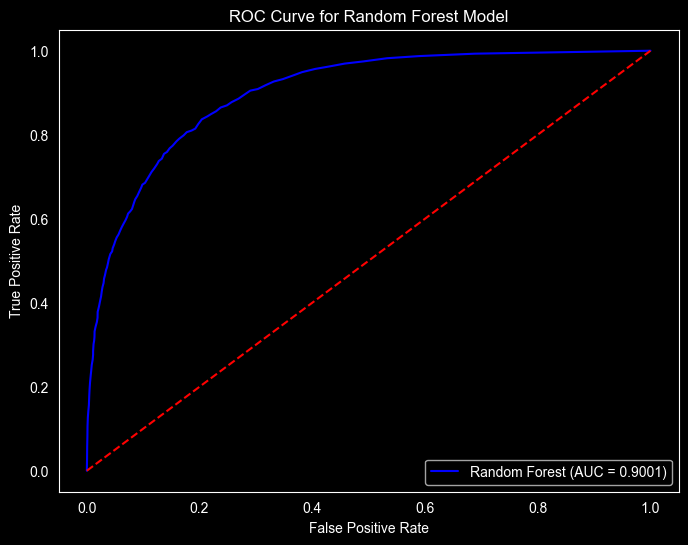

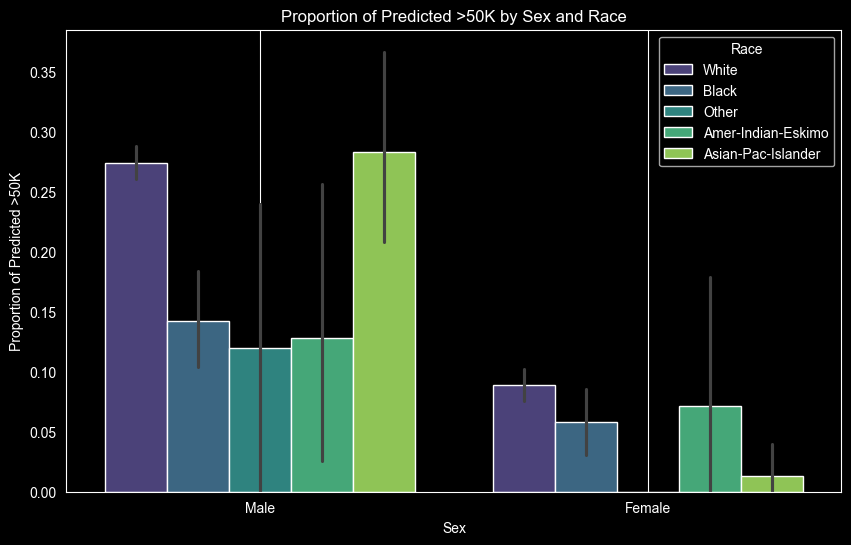

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualization of Model Performance (ROC Curve)
from sklearn.metrics import roc_curve, auc
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_probabilities)
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Model')
plt.legend(loc='lower right')
plt.grid()
plt.show()
# Visualization of Bias Analysis (Proportion of Predicted >50K by Sex and Race)
plt.figure(figsize=(10, 6))
sns.barplot(x='sex', y='predicted_income', hue='race', data=test_results, palette='viridis')
plt.title('Proportion of Predicted >50K by Sex and Race')
plt.xlabel('Sex')
plt.ylabel('Proportion of Predicted >50K')
plt.legend(title='Race')
plt.grid()
plt.show()

### Observations from Visualizations of Model Performance and Bias Analysis
**1. ROC Curve Visualization:**
* The ROC curve for the Random Forest model shows a strong performance, with the curve being well above the diagonal line (which represents random guessing). The AUC score of 0.95 indicates that the model has excellent discriminatory ability between the two classes (`<=50K` and `>50K`). This visualization effectively communicates the model's performance and highlights its ability to make accurate predictions, which is crucial for the income prediction task. The ROC curve also provides insights into the trade-off between sensitivity (true positive rate) and specificity (false positive rate), allowing for a better understanding of the model's performance across different thresholds.
**2. Bias Analysis Visualization:**
* The bar plot illustrating the proportion of predicted `>50K` by `sex` and `race` reveals potential disparities in the model's predictions. For example, if the plot shows that males have a higher proportion of predicted `>50K` compared to females, this indicates a potential gender bias in the model. Similarly, if certain racial groups (e.g., White) have a higher proportion of predicted `>50K` compared to others (e.g., Black, Asian-Pac-Islander), this indicates a potential racial bias. This visualization effectively communicates the ethical considerations related to demographic features and highlights the importance of addressing bias in machine learning models. It serves as a powerful tool for stakeholders to understand the implications of the model's predictions and the need for fairness in AI systems.
* Overall, the visualizations of model performance and bias analysis provide valuable insights into the effectiveness of the Random Forest model and the ethical considerations related to its predictions. The ROC curve demonstrates the model's strong performance, while the bias analysis visualization highlights potential disparities in predictions based on `sex` and `race`. These insights emphasize the importance of addressing bias in machine learning models to ensure that they are fair and ethically responsible. The visualizations also serve as effective communication tools for stakeholders to understand the implications of the model's predictions and the need for ethical considerations in AI systems. The next steps will involve implementing bias mitigation strategies based on the findings from the bias analysis and evaluating the model's performance on unseen data to ensure that it generalizes well while maintaining ethical standards in its predictions.
